In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install numpy pandas scikit-learn librosa soundfile matplotlib seaborn tensorflow joblib tqdm --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models

print("✅ Libraries loaded successfully.")

In [ ]:
DATA_ROOT = "/kaggle/input"  # Kaggle input path

# --- 2. FIND AUDIO FILES ---
audio_files = []
for ext in ("*.wav",):
    audio_files.extend(glob(os.path.join(DATA_ROOT, "**", ext), recursive=True))
print("Total audio files found:", len(audio_files))
print("Sample paths:", audio_files[:5])

# --- 3. LABEL EXTRACTION FROM FILENAME ---
def infer_label_from_filename(path):
   
    base = os.path.basename(path)
    parts = base.split('-')
    if len(parts) != 5:
        return "unknown"
    ff = parts[-1].split('.')[0]
    if ff == "01":
        return "fall"
    elif ff == "02":
        return "nofall"
    else:
        return "unknown"

rows = [{"path": f, "label": infer_label_from_filename(f)} for f in audio_files]
df_files = pd.DataFrame(rows)
print(df_files.label.value_counts())


Total audio files found: 950
Sample paths: ['/kaggle/input/fall-audio-detection-dataset/04-246-00-006-02.wav', '/kaggle/input/fall-audio-detection-dataset/07-272-00-107-02.wav', '/kaggle/input/fall-audio-detection-dataset/07-566-01-048-01.wav', '/kaggle/input/fall-audio-detection-dataset/02-520-04-075-01.wav', '/kaggle/input/fall-audio-detection-dataset/06-074-00-185-02.wav']
label
nofall    475
fall      475
Name: count, dtype: int64


In [ ]:
# --- 4. FEATURE EXTRACTION ---
SR = 22050
DURATION = 3.0
SAMPLES = int(SR * DURATION)

def load_audio(path, sr=SR, duration=DURATION):
    y, _ = librosa.load(path, sr=sr, duration=duration)
    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)))
    else:
        y = y[:SAMPLES]
    return y

def extract_features(path, sr=SR, n_mfcc=40):
    y = load_audio(path, sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spec_contrast_mean = np.mean(spec_contrast, axis=1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
    rms = np.mean(librosa.feature.rms(y=y))  # <-- FIXED
    return np.concatenate([mfcc_mean, mfcc_std, chroma_mean, spec_contrast_mean, [zcr, rms]])

features, labels, paths = [], [], []
for idx, row in tqdm(df_files.iterrows(), total=len(df_files)):
    try:
        feats = extract_features(row["path"])
        features.append(feats)
        labels.append(row["label"])
        paths.append(row["path"])
    except Exception as e:
        print("❌ Error processing:", row["path"], "->", e)

X = np.vstack(features)
y = np.array(labels)
print("✅ Features extracted:", X.shape)

100%|██████████| 950/950 [00:50<00:00, 19.00it/s]

✅ Features extracted: (950, 101)


In [ ]:
# --- 5. TRAIN/TEST SPLIT ---
le = LabelEncoder()
y_enc = le.fit_transform(y)  # 0 = fall, 1 = nofall

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
joblib.dump(scaler, "scaler.joblib")


['scaler.joblib']

Random Forest Classification Report:

              precision    recall  f1-score   support

        fall       0.99      0.98      0.98        95
      nofall       0.98      0.99      0.98        95

    accuracy                           0.98       190
   macro avg       0.98      0.98      0.98       190
weighted avg       0.98      0.98      0.98       190



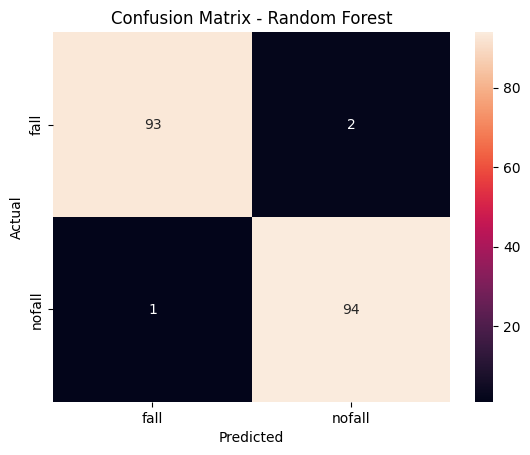

['rf_fall_detector.joblib']

In [ ]:
# --- 6. RANDOM FOREST CLASSIFIER ---
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred = rf.predict(X_test_s)

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
joblib.dump(rf, "rf_fall_detector.joblib")

100%|██████████| 190/190 [00:01<00:00, 104.59it/s]
I0000 00:00:1762182986.982623      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Spectrogram input shape: (760, 64, 130, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 128, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 62, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,586 (107.76 KB)

...

Epoch 1/20


I0000 00:00:1762182990.505293     128 service.cc:148] XLA service 0x7dae380061d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762182990.506063     128 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762182990.812703     128 cuda_dnn.cc:529] Loaded cuDNN version 90300


34/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4967 - loss: 0.6998

I0000 00:00:1762182993.142949     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.4974 - loss: 0.6985 - val_accuracy: 0.5316 - val_loss: 0.6833
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5517 - loss: 0.6844 - val_accuracy: 0.6895 - val_loss: 0.6613
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6299 - loss: 0.6591 - val_accuracy: 0.6684 - val_loss: 0.5808
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6757 - loss: 0.6044 - val_accuracy: 0.6895 - val_loss: 0.5388
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7305 - loss: 0.5665 - val_accuracy: 0.8105 - val_loss: 0.4861
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7667 - loss: 0.4952 - val_accuracy: 0.8474 - val_loss: 0.3621
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8223 - loss: 0.4196 - val_accuracy: 0.8526 - val_loss: 0.3214
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8167 - loss: 0.4073 - val_accuracy: 0.8789 - val_loss: 0.3323
Ep

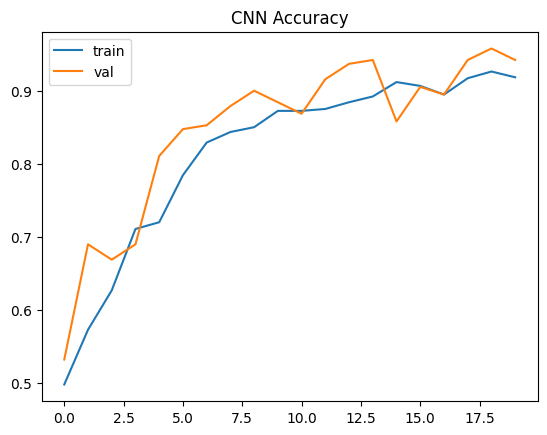

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9441 - loss: 0.1969
✅ CNN Accuracy: 0.942


In [ ]:
def make_mel_spectrogram(y, sr=SR, n_mels=64, hop_length=512):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    log_mel = librosa.power_to_db(mel)
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-9)
    return log_mel

def spectrogram_from_path(path):
    y = load_audio(path)
    S = make_mel_spectrogram(y)
    T = 130  # fixed length
    if S.shape[1] < T:
        S = np.pad(S, ((0,0),(0,T - S.shape[1])))
    else:
        S = S[:, :T]
    return S

# Split by indices to match train/test
indices = np.arange(len(paths))
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=y_enc, random_state=42)

X_train_spec = np.array([spectrogram_from_path(paths[i]) for i in tqdm(train_idx)])
X_test_spec  = np.array([spectrogram_from_path(paths[i]) for i in tqdm(test_idx)])
y_train_spec = y_enc[train_idx]
y_test_spec  = y_enc[test_idx]

X_train_spec = X_train_spec[..., np.newaxis]
X_test_spec = X_test_spec[..., np.newaxis]

print("Spectrogram input shape:", X_train_spec.shape)

# Build CNN
model = models.Sequential([
    layers.Input(shape=X_train_spec.shape[1:]),
    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(le.classes_), activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train_spec, y_train_spec,
    validation_data=(X_test_spec, y_test_spec),
    epochs=20, batch_size=16
)

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("CNN Accuracy")
plt.legend()
plt.show()

loss, acc = model.evaluate(X_test_spec, y_test_spec)
print(f"✅ CNN Accuracy: {acc:.3f}")
model.save("cnn_fall_detector.h5")


In [ ]:
def predict_audio_file(path):
    rf = joblib.load("rf_fall_detector.joblib")
    scaler = joblib.load("scaler.joblib")
    feats = extract_features(path)
    feats_s = scaler.transform([feats])
    pred = rf.predict(feats_s)[0]
    label = le.inverse_transform([pred])[0]
    proba = rf.predict_proba(feats_s).max()
    return label, proba

# Example usage:
test_file = paths[0]
label, prob = predict_audio_file(test_file)
print(f"Predicted: {label} ({prob:.2f})")

print("🎯 Notebook completed successfully.")

Predicted: nofall (0.97)
🎯 Notebook completed successfully.
